# 02 · Wine Quality — Multivariate Structure & Dimensionality (PCA, t-SNE)

## Part 2 — Multivariate Structure & Dimensionality

Part 1 looked at features one and two at a time. But 11 chemical measurements form a *joint*
structure that single correlations miss. We compress that structure with **PCA** (linear) and
**t-SNE** (nonlinear), and ask two questions:

1. does the chemistry **separate red from white**?
2. does any direction **track quality** — i.e. is quality a simple combination of the chemistry, or
   something more subtle?

The answers shape how we model: the biggest axis of variation turns out to be the wine *type*, not
the *quality* we actually care about.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
df = data.clean()
X = StandardScaler().fit_transform(df[data.NUMERIC])     # standardize: PCA is variance-driven
red = (df.wine_type == "red").to_numpy()
print("standardized feature matrix:", X.shape)

setup ok | numpy 2.1.3 | pandas 2.3.3


standardized feature matrix: (6497, 11)


### 1. PCA — how much structure, and in how many dimensions?

PCA rotates the 11 features into uncorrelated **components** ordered by variance captured. The scree
plot shows the chemistry is *not* dominated by one direction — it takes several components to explain
most of the variance (no single 'master' chemical axis).

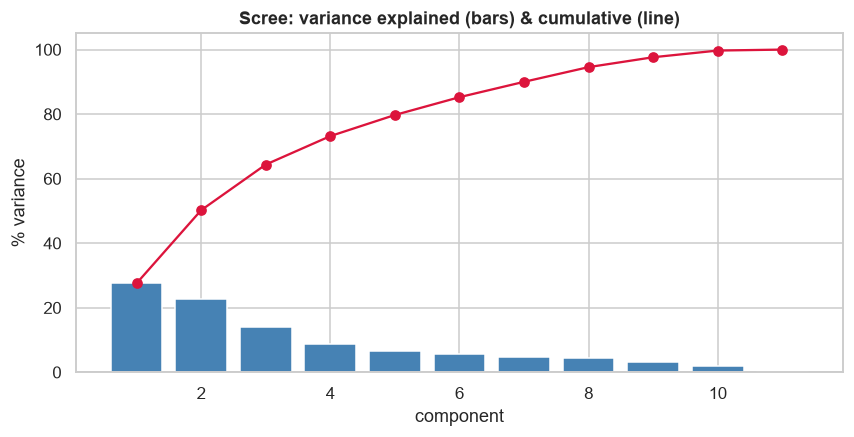

PC1 28% | PC2 23% | PC1+PC2 50% | components for 90%: 7


In [2]:
pca = PCA().fit(X); evr = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 12), evr*100, color="steelblue"); ax.plot(range(1, 12), evr.cumsum()*100, "o-", color="crimson")
ax.set_xlabel("component"); ax.set_ylabel("% variance"); ax.set_title("Scree: variance explained (bars) & cumulative (line)")
eda.savefig(fig, "p2_scree.png"); plt.show()
print("PC1 %.0f%% | PC2 %.0f%% | PC1+PC2 %.0f%% | components for 90%%: %d"
      % (evr[0]*100, evr[1]*100, evr[:2].sum()*100, (evr.cumsum() < 0.9).sum()+1))

### 2. The PCA map — coloured by type, then by quality

Project every wine onto PC1×PC2. Coloured by **type**, two clouds appear — the chemistry *almost
separates red and white on its own*. Coloured by **quality**, there's only a faint gradient — quality
is **not** a simple linear direction in the chemistry (which is exactly why it's hard to predict).

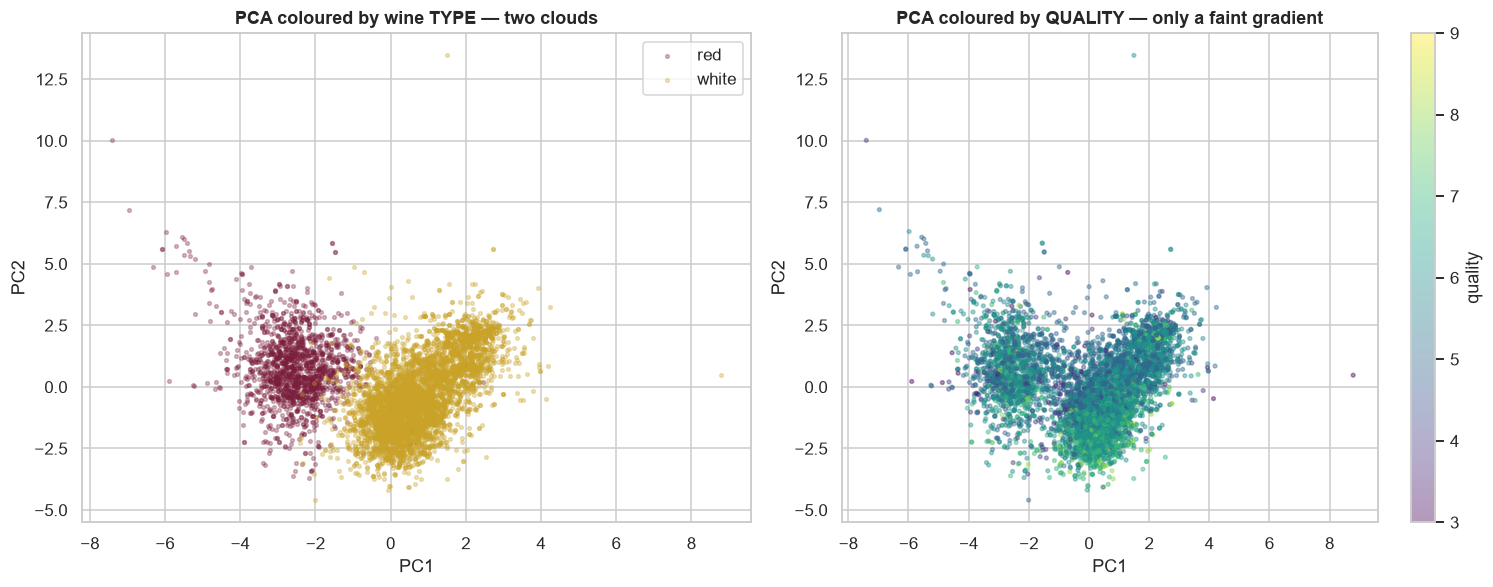

In [3]:
S = pca.transform(X)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for t, c in [("red", "#7B1E3B"), ("white", "#C9A227")]:
    m = (df.wine_type == t).to_numpy(); ax[0].scatter(S[m,0], S[m,1], s=6, alpha=.3, color=c, label=t)
ax[0].set_title("PCA coloured by wine TYPE — two clouds"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend()
sc = ax[1].scatter(S[:,0], S[:,1], s=6, alpha=.4, c=df.quality, cmap="viridis")
ax[1].set_title("PCA coloured by QUALITY — only a faint gradient"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.colorbar(sc, ax=ax[1], label="quality")
fig.tight_layout(); eda.savefig(fig, "p2_pca_map.png"); plt.show()

### 3. What do the components *mean*? — loadings

The **loadings** say which original features each component is built from. PC1 loads on **SO₂ and
sugar** (the white-wine markers) against **volatile acidity and chlorides** (the red markers) — it
*is* the type axis. The component that best correlates with quality is PC2.

In [4]:
load = pd.DataFrame(pca.components_[:3].T, index=data.NUMERIC, columns=["PC1","PC2","PC3"])
print(load.round(2).to_string())
for k in range(3):
    gap = abs(S[red,k].mean() - S[~red,k].mean()); qc = np.corrcoef(S[:,k], df.quality)[0,1]
    print("PC%d: red/white separation %.2f | corr with quality %+.2f" % (k+1, gap, qc))
print("\n-> PC1 = the red/white axis (variance 27%%); quality lives mostly on PC2 (corr -0.31), weakly.")

                       PC1   PC2   PC3
fixed_acidity        -0.24  0.34  0.43
volatile_acidity     -0.38  0.12 -0.31
citric_acid           0.15  0.18  0.59
residual_sugar        0.35  0.33 -0.16
chlorides            -0.29  0.32 -0.02
free_sulfur_dioxide   0.43  0.07 -0.13
total_sulfur_dioxide  0.49  0.09 -0.11
density              -0.04  0.58 -0.18
pH                   -0.22 -0.16 -0.46
sulphates            -0.29  0.19  0.07
alcohol              -0.11 -0.47  0.26
PC1: red/white separation 3.34 | corr with quality +0.08
PC2: red/white separation 1.03 | corr with quality -0.31
PC3: red/white separation 0.24 | corr with quality +0.22

-> PC1 = the red/white axis (variance 27%%); quality lives mostly on PC2 (corr -0.31), weakly.


### 4. t-SNE — a nonlinear map

PCA is linear; **t-SNE** preserves *local* neighbourhoods and often reveals clusters PCA blurs. On a
2,000-wine sample it shows the same story more vividly: two well-separated **type** clusters, but
quality smeared *within* them — confirming quality is a subtle, nonlinear signal.

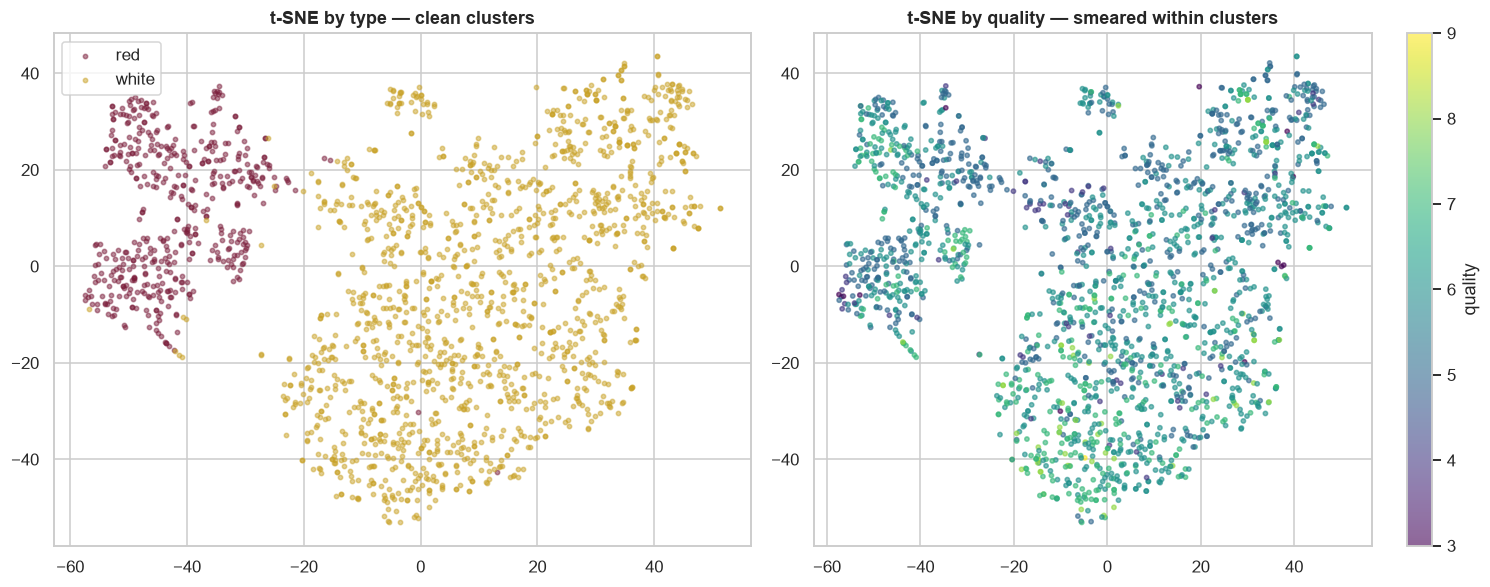

In [5]:
idx = np.random.default_rng(0).choice(len(X), 2000, replace=False)
emb = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(X[idx])
sub = df.iloc[idx]
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for t, c in [("red", "#7B1E3B"), ("white", "#C9A227")]:
    m = (sub.wine_type == t).to_numpy(); ax[0].scatter(emb[m,0], emb[m,1], s=8, alpha=.5, color=c, label=t)
ax[0].set_title("t-SNE by type — clean clusters"); ax[0].legend()
sc = ax[1].scatter(emb[:,0], emb[:,1], s=8, alpha=.6, c=sub.quality, cmap="viridis"); ax[1].set_title("t-SNE by quality — smeared within clusters")
plt.colorbar(sc, ax=ax[1], label="quality"); fig.tight_layout(); eda.savefig(fig, "p2_tsne.png"); plt.show()

### Takeaways

- The chemistry's **biggest axis of variation (PC1, 27%) is the wine *type*** — not quality. Whites
  and reds nearly separate on chemistry alone (PCA and t-SNE both show two clouds).
- **Quality is not a simple linear direction**: the best component for it (PC2) correlates only −0.31,
  and t-SNE smears quality *within* each type cluster — a clear signal that quality prediction is a
  **subtle, nonlinear** problem (favouring tree/nonlinear models, Part 5).
- A modeling implication: the dominant variance is a **nuisance** (type), so either model red and
  white separately or keep `wine_type` as a feature and let the model factor it out.

**Next — Part 3 (Feature engineering & transformations):** tame the skewed features, handle outliers,
and engineer chemically-meaningful features (acidity ratios, bound SO₂, sugar/alcohol balance) before
modelling.